In [1]:

import pandas as pd
import numpy as np

np.random.seed(42)

number_of_transactions = 10000

# Generate transaction timestamps
timestamps = pd.date_range(
    start="2026-01-01",
    end="2026-09-15",
    periods=number_of_transactions
)

data = {
    "transaction_id": [
        f"TXN{i:06d}" for i in range(1, number_of_transactions + 1)
    ],

    "customer_id": [
        f"CUST{np.random.randint(1, 2001):05d}"
        for _ in range(number_of_transactions)
    ],

    "amount": np.round(
        np.random.uniform(500, 500000, number_of_transactions), 2
    ),

    "payment_method": np.random.choice(
        ["Mobile Money", "Bank Transfer", "Card"],
        number_of_transactions
    ),

    "timestamp": timestamps,

    "location": np.random.choice(
        ["Kampala", "Jinja", "Mbarara", "Gulu", "Mbale"],
        number_of_transactions
    ),

    "device": np.random.choice(
        ["Android", "iPhone", "Web"],
        number_of_transactions
    ),

    "failed_attempts": np.random.poisson(
        0.5, number_of_transactions
    ),
}

df = pd.DataFrame(data)

# Create date and time columns
df["date"] = df["timestamp"].dt.date
df["time"] = df["timestamp"].dt.time

df.head()


,transaction_id,customer_id,amount,payment_method,timestamp,location,device,failed_attempts,date,time
0,TXN000001,CUST01127,228096.95,Mobile Money,2026-01-01 00:00:00.000000,Mbarara,Web,0,2026-01-01,00:00:00
1,TXN000002,CUST01460,241267.66,Mobile Money,2026-01-01 00:37:00.702070,Kampala,iPhone,0,2026-01-01,00:37:00.702070
2,TXN000003,CUST00861,379009.39,Bank Transfer,2026-01-01 01:14:01.404140,Gulu,Web,1,2026-01-01,01:14:01.404140
3,TXN000004,CUST01295,141318.22,Bank Transfer,2026-01-01 01:51:02.106210,Kampala,Web,0,2026-01-01,01:51:02.106210
4,TXN000005,CUST01131,159360.79,Mobile Money,2026-01-01 02:28:02.808280,Gulu,Android,1,2026-01-01,02:28:02.808280


In [2]:
df["hour"] = df["timestamp"].dt.hour

In [3]:
df["is_fraud"] = 0

fraud_condition = (
    (df["amount"] > 400000) &
    (df["hour"].isin([0, 1, 2, 3, 4]))
) | (
    df["failed_attempts"] >= 4
)

df.loc[fraud_condition, "is_fraud"] = 1

df["is_fraud"].value_counts()

is_fraud
0    9574
1     426
Name: count, dtype: int64

In [4]:
df["is_fraud"].value_counts()

is_fraud
0    9574
1     426
Name: count, dtype: int64

In [5]:
df["hour"] = df["timestamp"].dt.hour
df["date"] = df["timestamp"].dt.date
df["time"] = df["timestamp"].dt.time

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   transaction_id   10000 non-null  str           
 1   customer_id      10000 non-null  str           
 2   amount           10000 non-null  float64       
 3   payment_method   10000 non-null  str           
 4   timestamp        10000 non-null  datetime64[us]
 5   location         10000 non-null  str           
 6   device           10000 non-null  str           
 7   failed_attempts  10000 non-null  int64         
 8   date             10000 non-null  object        
 9   time             10000 non-null  object        
 10  hour             10000 non-null  int32         
 11  is_fraud         10000 non-null  int64         
dtypes: datetime64[us](1), float64(1), int32(1), int64(2), object(2), str(5)
memory usage: 898.6+ KB


In [7]:
df.describe()

,amount,timestamp,failed_attempts,hour,is_fraud
count,10000.000000,10000,10000.000000,10000.00000,10000.000000
mean,248328.701657,2026-05-09 11:59:59.999999,0.499800,11.49780,0.042600
min,526.390000,2026-01-01 00:00:00,0.000000,0.00000,0.000000
25%,123592.762500,2026-03-06 05:59:59.999999,0.000000,5.00000,0.000000
50%,245526.750000,2026-05-09 11:59:59.999999,0.000000,11.00000,0.000000
75%,374344.287500,2026-07-12 17:59:59.999999,1.000000,17.00000,0.000000
max,499902.670000,2026-09-15 00:00:00,5.000000,23.00000,1.000000
std,144036.396603,NaN,0.710388,6.92312,0.201964


In [8]:
df.isnull().sum()

transaction_id     0
customer_id        0
amount             0
payment_method     0
timestamp          0
location           0
device             0
failed_attempts    0
date               0
time               0
hour               0
is_fraud           0
dtype: int64

In [9]:
df.columns

Index(['transaction_id', 'customer_id', 'amount', 'payment_method',
       'timestamp', 'location', 'device', 'failed_attempts', 'date', 'time',
       'hour', 'is_fraud'],
      dtype='str')

In [10]:
df["is_fraud"] = 0

fraud_condition = (
    (df["amount"] > 400000) &
    (df["hour"].isin([0, 1, 2, 3, 4]))
) | (
    df["failed_attempts"] >= 4
)

df.loc[fraud_condition, "is_fraud"] = 1

In [11]:
df["is_fraud"].value_counts()

is_fraud
0    9574
1     426
Name: count, dtype: int64

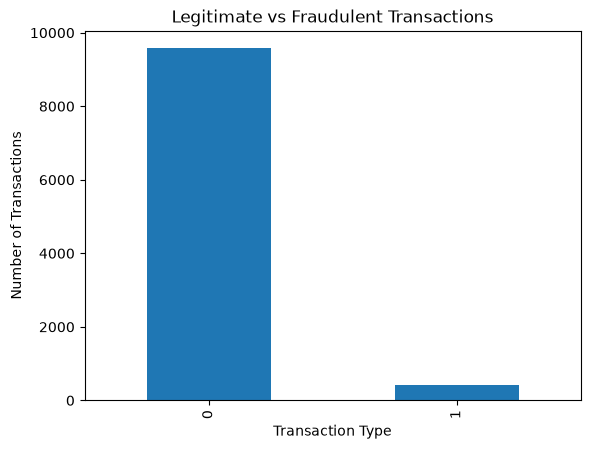

In [12]:
import matplotlib.pyplot as plt

df["is_fraud"].value_counts().plot(kind="bar")

plt.title("Legitimate vs Fraudulent Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.show()

In [13]:
df.groupby("is_fraud")["amount"].mean()

is_fraud
0    239671.593837
1    442890.087254
Name: amount, dtype: float64

In [14]:
model_df = pd.get_dummies(
    df,
    columns=[
        "payment_method",
        "location",
        "device"
    ],
    dtype=int
)

model_df.head()

,transaction_id,customer_id,amount,timestamp,failed_attempts,date,time,hour,is_fraud,payment_method_Bank Transfer,payment_method_Card,payment_method_Mobile Money,location_Gulu,location_Jinja,location_Kampala,location_Mbale,location_Mbarara,device_Android,device_Web,device_iPhone
0,TXN000001,CUST01127,228096.95,2026-01-01 00:00:00.000000,0,2026-01-01,00:00:00,0,0,0,0,1,0,0,0,0,1,0,1,0
1,TXN000002,CUST01460,241267.66,2026-01-01 00:37:00.702070,0,2026-01-01,00:37:00.702070,0,0,0,0,1,0,0,1,0,0,0,0,1
2,TXN000003,CUST00861,379009.39,2026-01-01 01:14:01.404140,1,2026-01-01,01:14:01.404140,1,0,1,0,0,1,0,0,0,0,0,1,0
3,TXN000004,CUST01295,141318.22,2026-01-01 01:51:02.106210,0,2026-01-01,01:51:02.106210,1,0,1,0,0,0,0,1,0,0,0,1,0
4,TXN000005,CUST01131,159360.79,2026-01-01 02:28:02.808280,1,2026-01-01,02:28:02.808280,2,0,0,0,1,1,0,0,0,0,1,0,0


In [15]:
features = [
    "amount",
    "hour",
    "failed_attempts"
]

features += [
    column
    for column in model_df.columns
    if column.startswith("payment_method_")
    or column.startswith("location_")
    or column.startswith("device_")
]

X = model_df[features]
y = model_df["is_fraud"]

In [16]:
X.head()

,amount,hour,failed_attempts,payment_method_Bank Transfer,payment_method_Card,payment_method_Mobile Money,location_Gulu,location_Jinja,location_Kampala,location_Mbale,location_Mbarara,device_Android,device_Web,device_iPhone
0,228096.95,0,0,0,0,1,0,0,0,0,1,0,1,0
1,241267.66,0,0,0,0,1,0,0,1,0,0,0,0,1
2,379009.39,1,1,1,0,0,1,0,0,0,0,0,1,0
3,141318.22,1,0,1,0,0,0,0,1,0,0,0,1,0
4,159360.79,2,1,0,0,1,1,0,0,0,0,1,0,0


In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [20]:
from sklearn.metrics import classification_report

predictions = model.predict(X_test)

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1915
           1       1.00      0.98      0.99        85

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



In [21]:
risk_scores = model.predict_proba(X_test)[:, 1]

results = X_test.copy()

results["actual_fraud"] = y_test.values
results["risk_score"] = risk_scores

results.head()

,amount,hour,failed_attempts,payment_method_Bank Transfer,payment_method_Card,payment_method_Mobile Money,location_Gulu,location_Jinja,location_Kampala,location_Mbale,location_Mbarara,device_Android,device_Web,device_iPhone,actual_fraud,risk_score
8805,24381.63,7,0,0,0,1,0,1,0,0,0,0,0,1,0,0.00
721,205765.80,12,0,1,0,0,0,0,1,0,0,1,0,0,0,0.00
7477,213167.93,4,1,0,0,1,1,0,0,0,0,1,0,0,0,0.00
6855,160721.82,4,0,1,0,0,0,0,1,0,0,0,0,1,0,0.01
1290,164872.35,3,0,1,0,0,0,0,1,0,0,0,1,0,0,0.00


In [22]:
results["risk_percentage"] = (
    results["risk_score"] * 100
).round(2)

results.head()

,amount,hour,failed_attempts,payment_method_Bank Transfer,payment_method_Card,payment_method_Mobile Money,location_Gulu,location_Jinja,location_Kampala,location_Mbale,location_Mbarara,device_Android,device_Web,device_iPhone,actual_fraud,risk_score,risk_percentage
8805,24381.63,7,0,0,0,1,0,1,0,0,0,0,0,1,0,0.00,0.0
721,205765.80,12,0,1,0,0,0,0,1,0,0,1,0,0,0,0.00,0.0
7477,213167.93,4,1,0,0,1,1,0,0,0,0,1,0,0,0,0.00,0.0
6855,160721.82,4,0,1,0,0,0,0,1,0,0,0,0,1,0,0.01,1.0
1290,164872.35,3,0,1,0,0,0,0,1,0,0,0,1,0,0,0.00,0.0


In [23]:
import joblib

joblib.dump(
    model,
    "../models/fraud_detection_model.pkl"
)

['../models/fraud_detection_model.pkl']

In [24]:
df.head()

,transaction_id,customer_id,amount,payment_method,timestamp,location,device,failed_attempts,date,time,hour,is_fraud
0,TXN000001,CUST01127,228096.95,Mobile Money,2026-01-01 00:00:00.000000,Mbarara,Web,0,2026-01-01,00:00:00,0,0
1,TXN000002,CUST01460,241267.66,Mobile Money,2026-01-01 00:37:00.702070,Kampala,iPhone,0,2026-01-01,00:37:00.702070,0,0
2,TXN000003,CUST00861,379009.39,Bank Transfer,2026-01-01 01:14:01.404140,Gulu,Web,1,2026-01-01,01:14:01.404140,1,0
3,TXN000004,CUST01295,141318.22,Bank Transfer,2026-01-01 01:51:02.106210,Kampala,Web,0,2026-01-01,01:51:02.106210,1,0
4,TXN000005,CUST01131,159360.79,Mobile Money,2026-01-01 02:28:02.808280,Gulu,Android,1,2026-01-01,02:28:02.808280,2,0


In [25]:
df.groupby("is_fraud")["amount"].agg(
    ["count", "mean", "min", "max"]
)

,count,mean,min,max
is_fraud,,,,
0,9574,239671.593837,526.39,499902.67
1,426,442890.087254,10295.46,499667.89


In [26]:
pd.crosstab(df["payment_method"], df["is_fraud"])

is_fraud,0,1
payment_method,,
Bank Transfer,3172,150
Card,3168,147
Mobile Money,3234,129


In [27]:
pd.crosstab(df["location"], df["is_fraud"])

is_fraud,0,1
location,,
Gulu,1894,81
Jinja,1881,79
Kampala,1850,93
Mbale,2008,87
Mbarara,1941,86


In [28]:
model_df = pd.get_dummies(
    df,
    columns=["payment_method", "location", "device"],
    dtype=int
)

features = [
    "amount",
    "hour",
    "failed_attempts"
]

features += [
    column
    for column in model_df.columns
    if column.startswith("payment_method_")
    or column.startswith("location_")
    or column.startswith("device_")
]

X = model_df[features]
y = model_df["is_fraud"]

print("Features:")
print(features)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['amount', 'hour', 'failed_attempts', 'payment_method_Bank Transfer', 'payment_method_Card', 'payment_method_Mobile Money', 'location_Gulu', 'location_Jinja', 'location_Kampala', 'location_Mbale', 'location_Mbarara', 'device_Android', 'device_Web', 'device_iPhone']

X shape: (10000, 14)
y shape: (10000,)


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training data: (8000, 14)
Testing data: (2000, 14)
Training labels: (8000,)
Testing labels: (2000,)


In [30]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [31]:
from sklearn.metrics import classification_report, confusion_matrix

predictions = model.predict(X_test)

print(classification_report(y_test, predictions))

print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1915
           1       1.00      0.98      0.99        85

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000

Confusion Matrix:
[[1915    0]
 [   2   83]]


In [32]:
risk_scores = model.predict_proba(X_test)[:, 1]

print("Number of risk scores:", len(risk_scores))
print("Minimum risk score:", risk_scores.min())
print("Maximum risk score:", risk_scores.max())
print("Average risk score:", risk_scores.mean())

Number of risk scores: 2000
Minimum risk score: 0.0
Maximum risk score: 1.0
Average risk score: 0.045845


In [33]:
all_risk_scores = model.predict_proba(X)[:, 1]

print("Number of risk scores:", len(all_risk_scores))
print("Minimum risk score:", all_risk_scores.min())
print("Maximum risk score:", all_risk_scores.max())
print("Average risk score:", all_risk_scores.mean())

Number of risk scores: 10000
Minimum risk score: 0.0
Maximum risk score: 1.0
Average risk score: 0.046022


In [34]:
pd.Series(all_risk_scores).describe()

count    10000.000000
mean         0.046022
std          0.198729
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
dtype: float64

In [35]:
pd.Series(all_risk_scores).value_counts().sort_index()

0.00    7911
0.01     799
0.02     367
0.03     164
0.04     106
0.05      80
0.06      44
0.07      33
0.08      23
0.09      13
0.10      11
0.11       5
0.12       7
0.13       1
0.14       2
0.15       2
0.16       1
0.20       2
0.21       1
0.23       1
0.26       1
0.35       1
0.46       1
0.51       1
0.75       1
0.83       3
0.84       1
0.85       1
0.86       2
0.87       2
0.88       6
0.89       2
0.90       2
0.91       6
0.92       5
0.93       4
0.94       2
0.95       5
0.96       6
0.97       7
0.98       6
0.99      10
1.00     352
Name: count, dtype: int64

In [36]:
df["failed_attempts"].value_counts().sort_index()

failed_attempts
0    6093
1    2978
2     785
3     128
4      14
5       2
Name: count, dtype: int64

In [37]:
df["risk_score"] = all_risk_scores

df.groupby("is_fraud")["risk_score"].agg(
    ["count", "mean", "min", "max"]
)

,count,mean,min,max
is_fraud,,,,
0,9574,0.004273,0.00,0.26
1,426,0.984296,0.35,1.00


In [38]:
df["status"] = "Successful"

df.loc[df["risk_score"] >= 0.30, "status"] = "Suspicious"

df.loc[df["failed_attempts"] >= 3, "status"] = "Failed"

df["status"].value_counts()

status
Successful    9447
Suspicious     409
Failed         144
Name: count, dtype: int64

In [39]:
df.groupby("status")["amount"].agg(
    ["count", "mean", "min", "max"]
)

,count,mean,min,max
status,,,,
Failed,144,235102.502708,3312.84,499135.35
Successful,9447,239764.995866,526.39,499902.67
Suspicious,409,450788.117922,401056.02,499667.89


In [40]:
final_df = df[
    [
        "transaction_id",
        "customer_id",
        "amount",
        "payment_method",
        "status",
        "location",
        "device",
        "timestamp",
        "date",
        "risk_score"
    ]
].copy()

final_df["risk_score"] = final_df["risk_score"].round(4)

final_df.head(10)

,transaction_id,customer_id,amount,payment_method,status,location,device,timestamp,date,risk_score
0,TXN000001,CUST01127,228096.95,Mobile Money,Successful,Mbarara,Web,2026-01-01 00:00:00.000000,2026-01-01,0.00
1,TXN000002,CUST01460,241267.66,Mobile Money,Successful,Kampala,iPhone,2026-01-01 00:37:00.702070,2026-01-01,0.00
2,TXN000003,CUST00861,379009.39,Bank Transfer,Successful,Gulu,Web,2026-01-01 01:14:01.404140,2026-01-01,0.05
3,TXN000004,CUST01295,141318.22,Bank Transfer,Successful,Kampala,Web,2026-01-01 01:51:02.106210,2026-01-01,0.01
4,TXN000005,CUST01131,159360.79,Mobile Money,Successful,Gulu,Android,2026-01-01 02:28:02.808280,2026-01-01,0.01
5,TXN000006,CUST01096,462358.57,Mobile Money,Suspicious,Gulu,Web,2026-01-01 03:05:03.510351,2026-01-01,1.00
6,TXN000007,CUST01725,28584.04,Bank Transfer,Successful,Gulu,Web,2026-01-01 03:42:04.212421,2026-01-01,0.01
7,TXN000008,CUST01045,243074.33,Mobile Money,Successful,Kampala,Web,2026-01-01 04:19:04.914491,2026-01-01,0.00
8,TXN000009,CUST01639,456444.00,Mobile Money,Suspicious,Mbarara,iPhone,2026-01-01 04:56:05.616561,2026-01-01,1.00
9,TXN000010,CUST00122,305376.32,Bank Transfer,Successful,Jinja,iPhone,2026-01-01 05:33:06.318631,2026-01-01,0.00


In [41]:
final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  10000 non-null  str           
 1   customer_id     10000 non-null  str           
 2   amount          10000 non-null  float64       
 3   payment_method  10000 non-null  str           
 4   status          10000 non-null  str           
 5   location        10000 non-null  str           
 6   device          10000 non-null  str           
 7   timestamp       10000 non-null  datetime64[us]
 8   date            10000 non-null  object        
 9   risk_score      10000 non-null  float64       
dtypes: datetime64[us](1), float64(2), object(1), str(6)
memory usage: 781.4+ KB


In [42]:
final_df["status"].value_counts()

status
Successful    9447
Suspicious     409
Failed         144
Name: count, dtype: int64

In [43]:
final_df["timestamp"] = final_df["timestamp"].dt.strftime("%Y-%m-%d %H:%M:%S")

final_df.head()

,transaction_id,customer_id,amount,payment_method,status,location,device,timestamp,date,risk_score
0,TXN000001,CUST01127,228096.95,Mobile Money,Successful,Mbarara,Web,2026-01-01 00:00:00,2026-01-01,0.00
1,TXN000002,CUST01460,241267.66,Mobile Money,Successful,Kampala,iPhone,2026-01-01 00:37:00,2026-01-01,0.00
2,TXN000003,CUST00861,379009.39,Bank Transfer,Successful,Gulu,Web,2026-01-01 01:14:01,2026-01-01,0.05
3,TXN000004,CUST01295,141318.22,Bank Transfer,Successful,Kampala,Web,2026-01-01 01:51:02,2026-01-01,0.01
4,TXN000005,CUST01131,159360.79,Mobile Money,Successful,Gulu,Android,2026-01-01 02:28:02,2026-01-01,0.01


In [44]:
final_df.to_csv(
    "../data/processed/securepay_transactions.csv",
    index=False
)

print("CSV saved successfully!")

CSV saved successfully!


In [45]:
check_df = pd.read_csv(
    "../data/processed/securepay_transactions.csv"
)

print("Shape:", check_df.shape)
print("\nColumns:")
print(check_df.columns.tolist())

print("\nMissing values:")
print(check_df.isnull().sum())

print("\nStatus distribution:")
print(check_df["status"].value_counts())

check_df.head()

Shape: (10000, 10)

Columns:
['transaction_id', 'customer_id', 'amount', 'payment_method', 'status', 'location', 'device', 'timestamp', 'date', 'risk_score']

Missing values:
transaction_id    0
customer_id       0
amount            0
payment_method    0
status            0
location          0
device            0
timestamp         0
date              0
risk_score        0
dtype: int64

Status distribution:
status
Successful    9447
Suspicious     409
Failed         144
Name: count, dtype: int64


,transaction_id,customer_id,amount,payment_method,status,location,device,timestamp,date,risk_score
0,TXN000001,CUST01127,228096.95,Mobile Money,Successful,Mbarara,Web,2026-01-01 00:00:00,2026-01-01,0.00
1,TXN000002,CUST01460,241267.66,Mobile Money,Successful,Kampala,iPhone,2026-01-01 00:37:00,2026-01-01,0.00
2,TXN000003,CUST00861,379009.39,Bank Transfer,Successful,Gulu,Web,2026-01-01 01:14:01,2026-01-01,0.05
3,TXN000004,CUST01295,141318.22,Bank Transfer,Successful,Kampala,Web,2026-01-01 01:51:02,2026-01-01,0.01
4,TXN000005,CUST01131,159360.79,Mobile Money,Successful,Gulu,Android,2026-01-01 02:28:02,2026-01-01,0.01


In [46]:
import joblib

joblib.dump(model, "../models/fraud_detection_model.pkl")

print("Fraud detection model saved successfully!")

Fraud detection model saved successfully!


In [47]:
import os

model_path = "../models/fraud_detection_model.pkl"

print("Model exists:", os.path.exists(model_path))
print("Model size:", os.path.getsize(model_path), "bytes")

Model exists: True
Model size: 1529417 bytes


In [48]:
feature_info = {
    "features": features
}

joblib.dump(
    feature_info,
    "../models/feature_info.pkl"
)

print("Feature information saved successfully!")
print("Number of features:", len(features))
print("Features:")
for feature in features:
    print("-", feature)

Feature information saved successfully!
Number of features: 14
Features:
- amount
- hour
- failed_attempts
- payment_method_Bank Transfer
- payment_method_Card
- payment_method_Mobile Money
- location_Gulu
- location_Jinja
- location_Kampala
- location_Mbale
- location_Mbarara
- device_Android
- device_Web
- device_iPhone


In [49]:
feature_path = "../models/feature_info.pkl"

print("Feature file exists:", os.path.exists(feature_path))
print("Feature file size:", os.path.getsize(feature_path), "bytes")

Feature file exists: True
Feature file size: 281 bytes


In [50]:
import joblib

saved_model = joblib.load("../models/fraud_detection_model.pkl")
saved_feature_info = joblib.load("../models/feature_info.pkl")

print("Model loaded successfully!")
print("Number of features:", len(saved_feature_info["features"]))

Model loaded successfully!
Number of features: 14


In [51]:
test_transaction = X_test.iloc[[0]]

prediction = saved_model.predict(test_transaction)[0]
risk_score = saved_model.predict_proba(test_transaction)[0][1]

print("Prediction:", prediction)
print("Risk score:", round(risk_score, 4))

Prediction: 0
Risk score: 0.0


In [52]:
suspicious_transaction = pd.DataFrame({
    "amount": [480000],
    "hour": [2],
    "failed_attempts": [0],
    "payment_method_Bank Transfer": [0],
    "payment_method_Card": [1],
    "payment_method_Mobile Money": [0],
    "location_Gulu": [0],
    "location_Jinja": [0],
    "location_Kampala": [1],
    "location_Mbale": [0],
    "location_Mbarara": [0],
    "device_Android": [1],
    "device_Web": [0],
    "device_iPhone": [0]
})

prediction = saved_model.predict(suspicious_transaction)[0]
risk_score = saved_model.predict_proba(suspicious_transaction)[0][1]

print("Prediction:", prediction)
print("Risk score:", round(risk_score, 4))

Prediction: 1
Risk score: 0.98
